# Find edge projectors - circuit cluster states
Created 13/08/2026

Objectives:
* Iterate on [this notebook](find_edge_projectors_initial_test.ipynb), use circuits to build larger cluster states and test on those, like in [this notebook](../../time_reversal_symmetries/truncating_reduced_density_matrices/random_fdlu_noising_mps_optimization.ipynb).
* Could eventually add FDLU noise, but no need right now.

# Package imports

In [8]:
import sys

In [9]:
from itertools import chain, combinations
from collections import defaultdict
import re

In [10]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os
import pickle

In [11]:
import numpy as np
import jax.numpy as jnp

import pandas as pd

import matplotlib.pyplot as plt
import matplotlib

In [12]:
import quimb as qu
import quimb.tensor as qtn
from quimb.tensor.optimize import TNOptimizer

In [13]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d

In [14]:
from itertools import cycle

# Definitions

## Construct cluster state

In [15]:
np_up_X_state = 1/(np.sqrt(2))*np.array([1,1])

In [16]:
qu_up_X_state = qtn.Tensor(
    data=np_up_X_state,
    inds=('k',),
    tags='prod'
)

In [17]:
np_CZ = np.diag([1,1,1,-1])

In [18]:
np_CZ = np_CZ.reshape((2,)*4)

In [19]:
qu_CZ = qtn.Tensor(
    data=np_CZ,
    inds=('k1', 'k2', 'b1', 'b2'),
    tags='CZ'
)

In [20]:
def get_cluster_state_qu_tensor_network(num_sites):
    assert (num_sites%2) == 0

    product_state_tensors = [
        qu_up_X_state.reindex({'k': f'kc_1_{i}'})
        for i in range(num_sites)
    ]

    first_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_1_{i}',
            'b2': f'kc_1_{i+1}',
            'k1': f'kc_2_{i}',
            'k2': f'kc_2_{i+1}'
        })
        for i in range(0, num_sites, 2)
    ]


    second_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_2_{i}',
            'b2': f'kc_2_{(i+1)%num_sites}',
            'k1': f'k{i}',
            'k2': f'k{(i+1)%num_sites}'
        })
        for i in range(1, num_sites+1, 2)
    ]

    all_tensors = (
        product_state_tensors
        + first_layer_circuit_tensors
        + second_layer_circuit_tensors
    )

    out = qtn.TensorNetwork(all_tensors, virtual=True)
    out.mangle_inner_()

    return out

In [21]:
psi = get_cluster_state_qu_tensor_network(32)

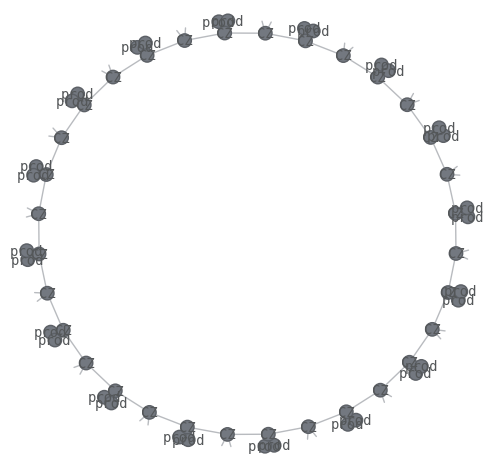

In [22]:
psi.draw()

Looks good. Weird, but good.

## Symmetries and effective density matrices

In [23]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])

In [24]:
qu_I = qtn.Tensor(np_I, inds=['k', 'b'])
qu_X = qtn.Tensor(np_X, inds=['k', 'b'])

In [25]:
symmetry_actions = [
    [qu_I, qu_I],
    [qu_I, qu_X],
    [qu_X, qu_I],
    [qu_X, qu_X]
]

In [26]:
symmetry_labels = [
    'II',
    'IX',
    'XI',
    'XX'
]

In [27]:
def generate_edm(cut_psi, sites, symmetry_pair, num_defect_sites):
    assert 2*num_defect_sites < len(sites)

    left_defect_sites = sites[:num_defect_sites]
    right_defect_sites = sites[-num_defect_sites:]
    internal_sites = sites[num_defect_sites:-num_defect_sites]

    # Being sloppy with the gate indices as the symmetries are invariant
    # under transpose and conjugation.
    left_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in left_defect_sites
    ]

    inner_gates = [
        symmetry_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in internal_sites
    ]

    right_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in right_defect_sites
    ]

    psi_bra_reindex_map = (
        {f'k{i}': f'c{i}' for i in left_defect_sites + right_defect_sites}
        | {f'k{i}': f'b{i}' for i in internal_sites}
    )

    edm = (
        cut_psi
        & left_sym_gates
        & inner_gates
        & right_sym_gates
        & cut_psi.conj().reindex(psi_bra_reindex_map)
    )

    edm = edm.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_defect_sites)),
        ('b_left', (f'b{i}' for i in left_defect_sites)),
        ('k_right', (f'k{i}' for i in right_defect_sites)),
        ('b_right', (f'b{i}' for i in right_defect_sites))
    ]

    edm.fuse(fuse_maps, inplace=True)

    return edm

## Optimisation functions

In [28]:
def solve_for_boundary_operators(edm, num_iters=20):
    # Careful, the indices are reversed here for ease.
    # i.e. the k, b indices have been swapped to make tensor contraction easier.
    scores = list()

    u_left = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('b_left'), edm.ind_size('k_left')),
        inds=['k_left', 'b_left'],
        dtype='complex64'
    )

    u_right = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('b_right'), edm.ind_size('k_right')),
        inds=['k_right', 'b_right'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (edm & u_left).contract()
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_right = qtn.Tensor(sol, inds = ['b_right', 'k_right'])
        
        left_edm = (edm & u_right).contract()
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_left = qtn.Tensor(sol, inds = ['b_left', 'k_left'])

    return (u_left, u_right), scores

## Extracting projectors

In [34]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [35]:
def maximize_projector_states(rho, left_rho_sites, right_rho_sites,
                              num_iters=20):
    scores = list()

    left_k_inds = [f'k{i}' for i in left_rho_sites]
    left_b_inds = [f'b{i}' for i in left_rho_sites]
    right_k_inds = [f'k{i}' for i in right_rho_sites]
    right_b_inds = [f'b{i}' for i in right_rho_sites]

    fused_rho = rho.fuse({
        'kl': left_k_inds,
        'kr': right_k_inds,
        'bl': left_b_inds,
        'br': right_b_inds
    })

    left_state = qtn.Tensor(
        data=random_uniform_complex((2**len(left_rho_sites),)),
        inds=['kl',]
    )
    
    right_state = qtn.Tensor(
        data=random_uniform_complex((2**len(right_rho_sites),)),
        inds=['kr',]
    )

    for i in range(num_iters):
        right_matrix = (
            fused_rho
            & left_state.conj()
            & left_state.reindex({'kl': 'bl'})
        ).contract()
        data = (
            right_matrix
            .transpose('kr', 'br')
            .data
        )

        eigvals, eigvecs = np.linalg.eig(data)

        index = np.argmax(np.abs(eigvals))
        score = np.abs(eigvals[index])
        state_data = eigvecs[:, index]

        right_state = qtn.Tensor(
            data=state_data,
            inds=['kr',]
        )
        scores.append(score)

        left_matrix = (
            fused_rho
            & right_state.conj()
            & right_state.reindex({'kr': 'br'})
        ).contract()
        data = (
            left_matrix
            .transpose('kl', 'bl')
            .data
        )

        eigvals, eigvecs = np.linalg.eig(data)

        index = np.argmax(np.abs(eigvals))
        score = np.abs(eigvals[index])
        state_data = eigvecs[:, index]

        left_state = qtn.Tensor(
            data=state_data,
            inds=['kl',]
        )
        scores.append(score)

    left_state.unfuse(
        {'kl': left_k_inds},
        shape_map={'kl': (2,)*len(left_k_inds)},
        inplace=True
    )
    right_state.unfuse(
        {'kr': right_k_inds},
        shape_map={'kr': (2,)*len(right_k_inds)},
        inplace=True
    )

    return scores, (left_state, right_state)

# Test

In [45]:
left_rho_sites = list(range(4, 6))
right_rho_sites = list(range(6, 8))

rho_sites = left_rho_sites + right_rho_sites

In [46]:
left_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in rho_sites})).contract()

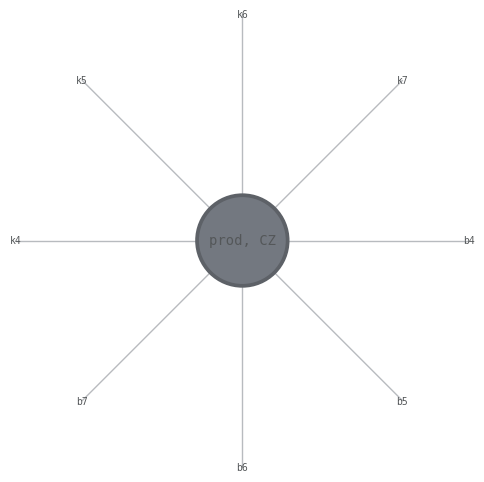

In [47]:
left_rho.draw()

In [48]:
left_state = qtn.Tensor(
    data=random_uniform_complex((2,)*len(left_rho_sites)),
    inds=[f'k{i}' for i in left_rho_sites]
)

right_state = qtn.Tensor(
    data=random_uniform_complex((2,)*len(right_rho_sites)),
    inds=[f'k{i}' for i in right_rho_sites]
)

In [49]:
left_out = maximize_projector_states(
    left_rho,
    left_rho_sites,
    right_rho_sites,
    num_iters=20
)

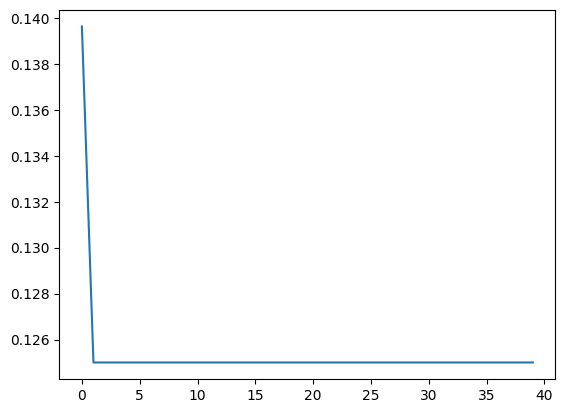

In [50]:
plt.plot(left_out[0])

In [51]:
left_out[0][-1]

0.12499999999999914

In [52]:
left_rho_sites = list(range(24, 26))
right_rho_sites = list(range(26, 28))

rho_sites = left_rho_sites + right_rho_sites

In [53]:
right_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in rho_sites})).contract()

In [54]:
right_out = maximize_projector_states(
    right_rho,
    left_rho_sites,
    right_rho_sites,
    num_iters=20
)

In [55]:
right_out[0][-1]

0.12499999999999918

In [56]:
left_out[1]

(Tensor(shape=(2, 2), inds=('k4', 'k5'), tags=oset([])),
 Tensor(shape=(2, 2), inds=('k6', 'k7'), tags=oset([])))

In [67]:
left_proj_state = left_out[1][1]
right_proj_state = right_out[1][0]

In [68]:
np.round(left_proj_state.data, 3)

array([[-0.001-0.007j, -0.044+0.368j],
       [ 0.016-0.004j,  0.929+0.j   ]])

In [69]:
np.round(right_proj_state.data, 3)

array([[-0.107+0.055j,  0.993+0.j   ],
       [ 0.   -0.j   ,  0.   -0.j   ]])

In [70]:
np.round(left_out[1][0].data, 3)

array([[ 0.736+0.j   , -0.493+0.465j],
       [-0.   -0.j   , -0.   +0.j   ]])

In [71]:
np.round(right_out[1][1].data, 3)

array([[-0.623+0.07j, -0.   -0.j  ],
       [ 0.779+0.j  ,  0.   +0.j  ]])

In [72]:
left_proj_state

Tensor(shape=(2, 2), inds=('k6', 'k7'), tags=oset([]))

In [73]:
right_proj_state

Tensor(shape=(2, 2), inds=('k24', 'k25'), tags=oset([]))

In [74]:
proj_psi = (
    psi.reindex({'k6': 'b6', 'k7': 'b7', 'k24': 'b24', 'k25': 'b25'})
    & left_proj_state.conj().reindex({'k6': 'b6', 'k7': 'b7'})
    & left_proj_state
    & right_proj_state.conj().reindex({'k24': 'b24', 'k25': 'b25'})
    & right_proj_state
)

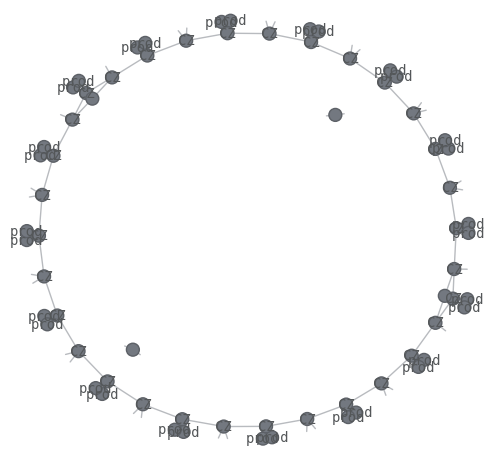

In [75]:
proj_psi.draw()

In [76]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [77]:
proj_psi = np.power(norm, -0.5)*proj_psi

In [78]:
norm = (
    proj_psi
    & proj_psi.conj()
).contract()

In [79]:
norm

(0.9999999999999982-8.405363685054862e-18j)

## Extract cut rho and EDM
Only have access to local information! So find "cut reduced density matrix", and extract state from this.

In fact for our purposes, don't need to extract state. That will only be relevant for the time reversal symmetries. Just need the effective density matrix.

In [80]:
cut_sites = list(range(6, 26))

In [81]:
cut_rho_unprojected = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in cut_sites}))

In [83]:
cut_rho = (
    cut_rho_unprojected.reindex(
        {
            'k6': 'l6',
            'k7': 'l7',
            'k24': 'l24',
            'k25': 'l25',
            'b6': 'c6',
            'b7': 'c7',
            'b24': 'c24',
            'b25': 'c25',
        }
    )
    & left_proj_state.conj().reindex({'k6': 'l6', 'k7': 'l7'})
    & left_proj_state
    & left_proj_state.reindex({'k6': 'c6', 'k7': 'c7'})
    & left_proj_state.conj().reindex({'k6': 'b6', 'k7': 'b7'})
    & right_proj_state.conj().reindex({'k24': 'l24', 'k25': 'l25'})
    & right_proj_state
    & right_proj_state.reindex({'k24': 'c24', 'k25': 'c25'})
    & right_proj_state.conj().reindex({'k24': 'b24', 'k25': 'b25'})
)

In [88]:
cut_rho = cut_rho.mangle_inner_()

In [89]:
cut_rho

TensorNetwork(tensors=136, indices=188)

In [109]:
cut_rho_trace = (
    cut_rho
    .reindex({f'b{i}': f'k{i}' for i in cut_sites})
    .contract()
)

In [110]:
cut_rho_trace

(0.0624999999999996+3.016211352809276e-19j)

In [111]:
cut_rho = cut_rho/cut_rho_trace

In [112]:
(
    cut_rho
    .reindex({f'b{i}': f'k{i}' for i in cut_sites})
    .contract()
)

(0.9999999999999998-2.5778352766002816e-17j)

In [100]:
def generate_edm_from_cut_rho(cut_rho, sites, symmetry_pair, num_defect_sites):
    # Lots of duplicate code, probably a better way to do this.
    assert 2*num_defect_sites < len(sites)

    left_defect_sites = sites[:num_defect_sites]
    right_defect_sites = sites[-num_defect_sites:]
    internal_sites = sites[num_defect_sites:-num_defect_sites]

    # Being sloppy with the gate indices as the symmetries are invariant
    # under transpose and conjugation.
    left_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in left_defect_sites
    ]

    inner_gates = [
        symmetry_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in internal_sites
    ]

    right_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in right_defect_sites
    ]

    reindex_map = {
        f'b{i}': f'c{i}'
        for i in (left_defect_sites + right_defect_sites)
    }

    edm = (
        cut_rho.reindex(reindex_map)
        & left_sym_gates
        & inner_gates
        & right_sym_gates
    )

    edm = edm.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_defect_sites)),
        ('b_left', (f'b{i}' for i in left_defect_sites)),
        ('k_right', (f'k{i}' for i in right_defect_sites)),
        ('b_right', (f'b{i}' for i in right_defect_sites))
    ]

    edm.fuse(fuse_maps, inplace=True)

    return edm

In [115]:
edm = generate_edm_from_cut_rho(
    cut_rho,
    cut_sites,
    symmetry_actions[1],
    4
)

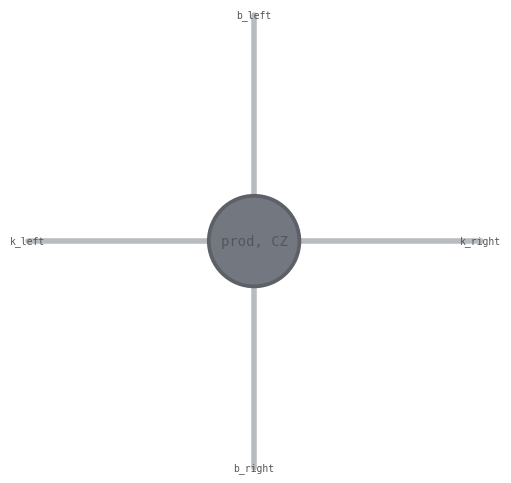

In [116]:
edm.draw()

In [117]:
edm.ind_size('k_left')

16

In [118]:
defect_ops_out = solve_for_boundary_operators(edm, num_iters=20)

In [119]:
defect_ops_out[1]

[0.6775674727328488,
 1.0000000000000002,
 1.0000000000000002,
 1.0000000000000004,
 1.0,
 1.0000000000000002,
 1.0,
 1.0000000000000002,
 1.0000000000000004,
 0.9999999999999998,
 1.0000000000000002,
 1.0000000000000002,
 1.0,
 1.0000000000000002,
 1.0000000000000004,
 1.0,
 1.0,
 1.0000000000000002,
 0.9999999999999999,
 1.0000000000000002,
 1.000000000000001,
 1.0,
 1.0,
 1.0000000000000002,
 1.0,
 1.0000000000000007,
 1.0,
 1.0000000000000007,
 1.0000000000000007,
 0.9999999999999992,
 0.9999999999999998,
 1.0000000000000004,
 1.0000000000000004,
 1.0,
 1.0,
 1.0000000000000002,
 1.0000000000000002,
 1.0,
 1.0,
 1.0000000000000004]

In [120]:
edms = [
    generate_edm_from_cut_rho(
        cut_rho,
        cut_sites,
        s,
        4
    )
    for s in symmetry_actions[1:]
]

In [121]:
defect_ops_results = [
    solve_for_boundary_operators(edm, num_iters=20)
    for edm in edms
]

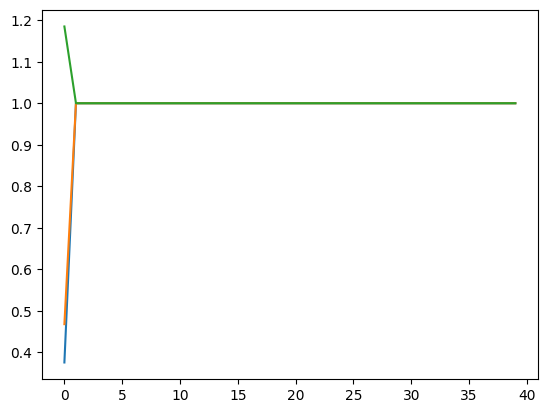

In [122]:
for l in defect_ops_results:
    plt.plot(l[1])

In [123]:
[l[1][-1] for l in defect_ops_results]

[1.0000000000000002, 1.0000000000000007, 1.0000000000000007]

## SPT extraction functions

In [124]:
symmetry_combination_labels = list(combinations(symmetry_labels, 2))

In [125]:
symmetry_combination_labels

[('II', 'IX'),
 ('II', 'XI'),
 ('II', 'XX'),
 ('IX', 'XI'),
 ('IX', 'XX'),
 ('XI', 'XX')]

In [126]:
e, a, b, c = symmetry_labels

In [127]:
group_products = [
    (a, b, c),
    (b, a, c),
    (a, c, b),
    (c, a, b),
    (c, b, a),
    (b, c, a)
]

In [128]:
defect_ops_results[0][0][1]

Tensor(shape=(16, 16), inds=('b_right', 'k_right'), tags=oset([]))

In [129]:
def get_proj_rep_phase(cut_rho, r_g, r_h, r_gh, u_g, left_right):
    k_ind = f'k_{left_right}'
    b_ind = f'b_{left_right}'

    invariant_tn = (
        cut_rho
        & r_g.reindex({b_ind: 'i1'})
        & u_g.conj().reindex({k_ind: 'i1', b_ind: 'i2'})
        & r_h.reindex({k_ind: 'i2', b_ind: 'i3'})
        & u_g.reindex({b_ind: 'i3', k_ind: 'i4'})
        & r_gh.conj().reindex({b_ind: 'i4', k_ind: b_ind})
    )

    out = invariant_tn.contract()

    return out

In [130]:
symmetry_labels

['II', 'IX', 'XI', 'XX']

In [131]:
def get_defect_symmetry_gate(symmetry_label, defect_sites, left_right):
    sym_pair = next(
        pair for label, pair in zip(symmetry_labels, symmetry_actions)
    )

    sym_gates = [
        sym_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in defect_sites
    ]

    fuse_map = [
        (f'k_{left_right}', (f'k{i}' for i in defect_sites)),
        (f'b_{left_right}', (f'b{i}' for i in defect_sites))
    ]
   
    gate = (
        qtn
        .TensorNetwork(sym_gates)
        .contract()
        .fuse(fuse_map)
    )

    return gate

In [132]:
def get_proj_rep_phases(rho, unitaries, left_right, defect_sites):
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    out_phases = list()
    for a, b, c in group_products:
        sym_gate = get_defect_symmetry_gate(
            a, defect_sites, left_right
        )

        phase = get_proj_rep_phase(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c],
            sym_gate,
            left_right
        )

        out_phases.append(phase)

    return out_phases

In [134]:
left_rdm = (
    cut_rho
    .reindex({
        f'b{i}': f'k{i}'
        for i in cut_sites if i not in left_defect_sites
    })
)
left_rdm = left_rdm.contract()
fuse_map = [
    ('k_left', (f'k{i}' for i in left_defect_sites)),
    ('b_left', (f'b{i}' for i in left_defect_sites))
]
left_rdm.fuse(fuse_map, inplace=True)

right_rdm = (
    cut_rho
    .reindex({
        f'b{i}': f'k{i}'
        for i in cut_sites if i not in right_defect_sites
    })
)
right_rdm = right_rdm.contract()
fuse_map = [
    ('k_right', (f'k{i}' for i in right_defect_sites)),
    ('b_right', (f'b{i}' for i in right_defect_sites))
]
right_rdm.fuse(fuse_map, inplace=True)

Tensor(shape=(16, 16), inds=('k_right', 'b_right'), tags=oset(['prod', 'CZ']))

In [135]:
left_rdm

Tensor(shape=(16, 16), inds=('k_left', 'b_left'), tags=oset(['prod', 'CZ']))

In [136]:
right_rdm

Tensor(shape=(16, 16), inds=('k_right', 'b_right'), tags=oset(['prod', 'CZ']))

In [137]:
unitary_pairs = [l[0] for l in defect_ops_results]
left_unitaries, right_unitaries = zip(*unitary_pairs)

In [138]:
left_phases = np.array(get_proj_rep_phases(left_rdm, left_unitaries, 'left', left_defect_sites))

In [139]:
left_phases

array([ 0.27988421+0.48713942j,  0.52845379+0.32004783j,
        0.03235925-0.21202857j,  0.09586279+0.35154629j,
        0.15586599-0.14262698j, -0.56426626-0.34088029j])

In [140]:
left_phases[::2]/left_phases[1::2]

array([ 0.79596161+0.43976151j, -0.5380237 -0.23876145j,
       -0.09050063+0.30743794j])

In [141]:
right_phases = np.array(get_proj_rep_phases(
    right_rdm,
    right_unitaries,
    'right',
    right_defect_sites
))

In [142]:
right_phases

array([ 0.07704958+0.62836091j, -0.06650502+0.07086182j,
        0.15855186-0.22977818j, -0.07027913+0.34044384j,
        0.06364069-0.09134856j, -0.0392191 +0.20575437j])

In [143]:
right_phases[::2]/right_phases[1::2]

array([ 4.17209826-5.00290691j, -0.73956135-0.31305055j,
       -0.48529384-0.21680172j])

Invariants are totally wrong, shoot.

## 6 sites

In [145]:
edms = [
    generate_edm_from_cut_rho(
        cut_rho,
        cut_sites,
        s,
        6
    )
    for s in symmetry_actions[1:]
]

In [146]:
defect_ops_results = [
    solve_for_boundary_operators(edm, num_iters=20)
    for edm in edms
]

In [147]:
[l[1][-1] for l in defect_ops_results]

[1.000000000000003, 1.0000000000000029, 1.0000000000000029]

In [155]:
num_defect_sites=6

In [156]:
left_defect_sites = list(
    range(min(cut_sites),min(cut_sites) + num_defect_sites)
)

right_defect_sites = list(
    range(max(cut_sites) - num_defect_sites, max(cut_sites))
)

In [157]:
left_rdm = (
    cut_rho
    .reindex({
        f'b{i}': f'k{i}'
        for i in cut_sites if i not in left_defect_sites
    })
)
left_rdm = left_rdm.contract()
fuse_map = [
    ('k_left', (f'k{i}' for i in left_defect_sites)),
    ('b_left', (f'b{i}' for i in left_defect_sites))
]
left_rdm.fuse(fuse_map, inplace=True)

right_rdm = (
    cut_rho
    .reindex({
        f'b{i}': f'k{i}'
        for i in cut_sites if i not in right_defect_sites
    })
)
right_rdm = right_rdm.contract()
fuse_map = [
    ('k_right', (f'k{i}' for i in right_defect_sites)),
    ('b_right', (f'b{i}' for i in right_defect_sites))
]
right_rdm.fuse(fuse_map, inplace=True)

Tensor(shape=(64, 64), inds=('k_right', 'b_right'), tags=oset(['prod', 'CZ']))

In [158]:
unitary_pairs = [l[0] for l in defect_ops_results]
left_unitaries, right_unitaries = zip(*unitary_pairs)

In [159]:
left_phases = np.array(get_proj_rep_phases(left_rdm, left_unitaries, 'left', left_defect_sites))

In [160]:
left_phases

array([-0.58940236-0.00396242j,  0.65413829+0.14260358j,
        0.20629928-0.09949606j,  0.28516688+0.11856062j,
       -0.31010712-0.23187475j, -0.33320564-0.57417228j])

In [161]:
left_phases[::2]/left_phases[1::2]

array([-0.86141802+0.18173355j,  0.49313273-0.55392894j,
        0.53656819-0.22871109j])

In [162]:
right_phases = np.array(get_proj_rep_phases(
    right_rdm,
    right_unitaries,
    'right',
    right_defect_sites
))

In [163]:
right_phases

array([-0.02651534+0.07574239j,  0.0527623 -0.04182447j,
        0.04112667-0.1341238j ,  0.12976482+0.0096017j ,
       -0.04406451+0.0219072j ,  0.09381159+0.04245296j])

In [164]:
right_phases[::2]/right_phases[1::2]

array([-1.00744496+0.63694237j,  0.2391444 -1.05128645j,
       -0.30215749+0.37026001j])

# Conclusions
Making things bigger doesn't seem to help.